In [1]:
import pandas as pd

In [8]:
train = pd.read_csv(r'D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\train.csv')

In [5]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [9]:
train = train[(train['store'] == 1)&(train['item'] == 1)]



In [10]:
test = pd.read_csv(r'D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\test.csv')

In [11]:
test.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [12]:
test = test[(test['store'] == 1)&(test['item'] == 1)]

In [13]:
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

In [14]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [15]:
train = train.sort_values('date')
train_data = train.iloc[:-30]
val_data = train.iloc[-30:]

In [45]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['sales'], order=(1,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

In [20]:
from statsmodels.tsa.arima.model import ARIMA

In [46]:
model = ARIMA(train_data['sales'], order = (1,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps = len(val_data))

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(val_data['sales'], forecast)
mae

4.079659466573193

In [43]:
from statsmodels.tsa.stattools import adfuller

In [31]:
results  = adfuller(train['sales'])

print("ADF Statistic:", results[0])
print("p-value:", results[1])

ADF Statistic: -3.157670556332822
p-value: 0.022569380626570396


In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt


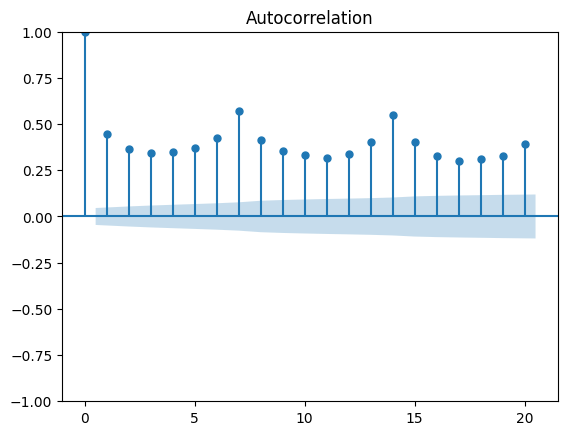

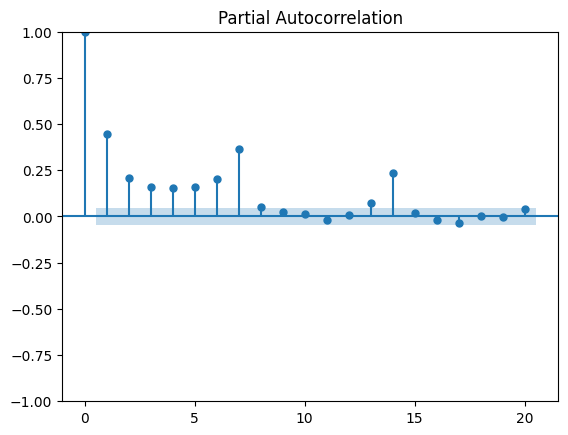

In [36]:
plot_acf(train['sales'], lags=20)
plot_pacf(train['sales'], lags=20)
plt.show()

In [38]:
from statsmodels.tsa.stattools import adfuller

def get_d(series):
    d = 0
    p_value = adfuller(series)[1]
    
    while p_value > 0.05:
        series = series.diff().dropna()
        d += 1
        p_value = adfuller(series)[1]
    
    return d

d = get_d(train['sales'])
print("Optimal d:", d)

Optimal d: 0


In [44]:
import itertools
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import numpy as np

# assume you already created:
# train_data = train.iloc[:-30]
# val_data   = train.iloc[-30:]

p_values = range(0, 8)   # small grid for speed
d_values = [0, 1]        # try both (ADF suggested 0, but we test 1 too)
q_values = range(0, 5)

results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(train_data['sales'], order=(p, d, q))
        fitted = model.fit()
        
        preds = fitted.forecast(steps=len(val_data))
        mae = mean_absolute_error(val_data['sales'], preds)
        
        results.append(((p, d, q), mae))
        
    except:
        continue

# sort by MAE (lower is better)
results_sorted = sorted(results, key=lambda x: x[1])

# show top candidates
for order, mae in results_sorted[:5]:
    print(order, mae)

best_order, best_mae = results_sorted[0]
print("Best order:", best_order)
print("Best MAE:", best_mae)

(1, 1, 0) 4.079659466573193
(5, 1, 0) 4.216580768076969
(4, 1, 0) 4.226633241153528
(3, 1, 0) 4.361089710611646
(0, 1, 0) 4.4
Best order: (1, 1, 0)
Best MAE: 4.079659466573193


In [51]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# -------------------------------
# 1. Load data
# -------------------------------
train = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\train.csv")
test = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\test.csv")

train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

train = train.sort_values('date')

# -------------------------------
# 2. Prepare output
# -------------------------------
all_predictions = []

# -------------------------------
# 3. Loop over each (store, item)
# -------------------------------
for (store, item), group in train.groupby(['store', 'item']):
    
    group = group.sort_values('date')
    
    # corresponding test data
    test_group = test[(test['store'] == store) & (test['item'] == item)]
    
    # -------------------------------
    # Train ARIMA
    # -------------------------------
    model = ARIMA(group['sales'], order=(1,1,0))
    model_fit = model.fit()
    
    # -------------------------------
    # Forecast
    # -------------------------------
    forecast_steps = len(test_group)
    forecast = model_fit.forecast(steps=forecast_steps)
    
    # -------------------------------
    # Assign predictions
    # -------------------------------
    test_group = test_group.copy()
    test_group['sales'] = forecast.values
    
    all_predictions.append(test_group)

# -------------------------------
# 4. Combine all results
# -------------------------------
final_output = pd.concat(all_predictions)

# -------------------------------
# 5. Save CSV
# -------------------------------
final_output[['date', 'store', 'item', 'sales']].to_csv(
    r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\output\ARIMA_out.csv",
    index=False
)

print("Forecast saved as ARIMA_out.csv")

Forecast saved as ARIMA_out.csv


In [56]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

# -------------------------------
# 1. Load data
# -------------------------------
train = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\train.csv")
test = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\test.csv")

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

train = train.sort_values(["store", "item", "date"]).reset_index(drop=True)
test = test.sort_values(["store", "item", "date"]).reset_index(drop=True)

# -------------------------------
# 2. Feature engineering for TRAIN
# -------------------------------
def add_features_train(df):
    df = df.sort_values("date").copy()

    df["lag_1"] = df["sales"].shift(1)
    df["lag_7"] = df["sales"].shift(7)
    df["lag_14"] = df["sales"].shift(14)

    # rolling features must use only past values
    df["rolling_mean_7"] = df["sales"].shift(1).rolling(7, min_periods=1).mean()
    df["rolling_mean_28"] = df["sales"].shift(1).rolling(28, min_periods=1).mean()

    df["dayofweek"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    return df

train_fe = train.groupby(["store", "item"], group_keys=False).apply(add_features_train)
train_fe = train_fe.dropna(subset=["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_mean_28"]).copy()

# -------------------------------
# 3. Train XGBoost on log target
# -------------------------------
features = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_28",
    "dayofweek", "month", "day",
    "store", "item"
]

X_train = train_fe[features]
y_train = np.log1p(train_fe["sales"])   # log transform helps a lot for sales

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# -------------------------------
# 4. Recursive forecasting per (store, item)
# -------------------------------
all_preds = []

for (store, item), tr_group in train.groupby(["store", "item"]):
    tr_group = tr_group.sort_values("date").copy()
    te_group = test[(test["store"] == store) & (test["item"] == item)].sort_values("date").copy()

    if te_group.empty:
        continue

    # history contains only actual + predicted sales
    history_sales = tr_group["sales"].tolist()

    for idx, row in te_group.iterrows():
        current_date = row["date"]

        # build features from history
        lag_1 = history_sales[-1] if len(history_sales) >= 1 else 0
        lag_7 = history_sales[-7] if len(history_sales) >= 7 else history_sales[0]
        lag_14 = history_sales[-14] if len(history_sales) >= 14 else history_sales[0]

        rolling_mean_7 = np.mean(history_sales[-7:]) if len(history_sales) >= 7 else np.mean(history_sales)
        rolling_mean_28 = np.mean(history_sales[-28:]) if len(history_sales) >= 28 else np.mean(history_sales)

        feat_row = pd.DataFrame([{
            "lag_1": lag_1,
            "lag_7": lag_7,
            "lag_14": lag_14,
            "rolling_mean_7": rolling_mean_7,
            "rolling_mean_28": rolling_mean_28,
            "dayofweek": current_date.dayofweek,
            "month": current_date.month,
            "day": current_date.day,
            "store": store,
            "item": item
        }])

        pred_log = model.predict(feat_row[features])[0]
        pred = np.expm1(pred_log)

        # sales cannot be negative
        pred = max(0, float(pred))

        te_group.loc[idx, "sales"] = pred
        history_sales.append(pred)

    all_preds.append(te_group)

# -------------------------------
# 5. Combine and save
# -------------------------------
final_output = pd.concat(all_preds, ignore_index=True)
final_output = final_output[["date", "store", "item", "sales"]].sort_values(["store", "item", "date"])

out_path = r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\output\XGB_out.csv"
final_output.to_csv(out_path, index=False)

print("Saved:", out_path)
print(final_output.head(10))
print(final_output["sales"].describe())

Saved: D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\output\XGB_out.csv
        date  store  item      sales
0 2018-01-01      1     1  12.908086
1 2018-01-02      1     1  14.677706
2 2018-01-03      1     1  15.015007
3 2018-01-04      1     1  15.963787
4 2018-01-05      1     1  16.278236
5 2018-01-06      1     1  18.053083
6 2018-01-07      1     1  18.655394
7 2018-01-08      1     1  12.457556
8 2018-01-09      1     1  14.503880
9 2018-01-10      1     1  14.320255
count    45000.000000
mean        46.065471
std         22.905428
min          7.252208
25%         26.721880
50%         43.502304
75%         61.810576
max        127.835358
Name: sales, dtype: float64


In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# # -------------------------------
# # 1. Load data
# # -------------------------------
# train = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\train.csv")
# test = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\test.csv")

# train['date'] = pd.to_datetime(train['date'])
# test['date'] = pd.to_datetime(test['date'])

# train = train.sort_values(['store','item','date'])

# # -------------------------------
# # 2. Use ONE series (fast for interview)
# # -------------------------------
# train = train[(train['store']==1) & (train['item']==1)]
# test = test[(test['store']==1) & (test['item']==1)]

# # -------------------------------
# # 3. Scale data
# # -------------------------------
# scaler = MinMaxScaler()
# scaled = scaler.fit_transform(train[['sales']])

# # -------------------------------
# # 4. Create sequences
# # -------------------------------
# SEQ_LEN = 30

# def create_sequences(data, seq_len):
#     X, y = [], []
#     for i in range(len(data) - seq_len):
#         X.append(data[i:i+seq_len])
#         y.append(data[i+seq_len])
#     return np.array(X), np.array(y)

# X, y = create_sequences(scaled, SEQ_LEN)

# # -------------------------------
# # 5. Build LSTM model
# # -------------------------------
# model = Sequential([
#     LSTM(50, activation='relu', input_shape=(SEQ_LEN,1)),
#     Dense(1)
# ])

# model.compile(optimizer='adam', loss='mse')

# # -------------------------------
# # 6. Train
# # -------------------------------
# model.fit(X, y, epochs=5, batch_size=32, verbose=1)

# # -------------------------------
# # 7. Recursive prediction
# # -------------------------------
# last_seq = scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)

# predictions = []

# for i in range(len(test)):
#     pred = model.predict(last_seq, verbose=0)[0][0]
#     predictions.append(pred)
    
#     # update sequence
#     last_seq = np.append(last_seq[:,1:,:], [[[pred]]], axis=1)

# # -------------------------------
# # 8. Inverse scaling
# # -------------------------------
# predictions = scaler.inverse_transform(np.array(predictions).reshape(-1,1))

# # -------------------------------
# # 9. Save output
# # -------------------------------
# test['sales'] = predictions

# test[['date','store','item','sales']].to_csv(
#     r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\output\LSTM_out.csv",
#     index=False
# )

# print("Saved LSTM_out.csv")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

train = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\train.csv")
test = pd.read_csv(r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\data\test.csv")

train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

train = train.sort_values(['store','item','date'])
test = test.sort_values(['store','item','date'])

SEQ_LEN = 30
all_preds = []

for (store, item), group in train.groupby(['store','item']):
    
    group = group.sort_values('date')
    test_group = test[(test['store']==store) & (test['item']==item)].copy()
    
    if len(test_group) == 0:
        continue

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(group[['sales']])

    # create sequences
    X, y = [], []
    for i in range(len(scaled)-SEQ_LEN):
        X.append(scaled[i:i+SEQ_LEN])
        y.append(scaled[i+SEQ_LEN])
    
    X, y = np.array(X), np.array(y)

    # build model
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(SEQ_LEN,1)),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=3, batch_size=32, verbose=0)

    # recursive prediction
    last_seq = scaled[-SEQ_LEN:].reshape(1, SEQ_LEN, 1)
    preds = []

    for i in range(len(test_group)):
        pred = model.predict(last_seq, verbose=0)[0][0]
        preds.append(pred)
        last_seq = np.append(last_seq[:,1:,:], [[[pred]]], axis=1)

    preds = scaler.inverse_transform(np.array(preds).reshape(-1,1))
    
    test_group['sales'] = preds
    all_preds.append(test_group)

# combine all
final_output = pd.concat(all_preds)

# save
final_output[['date','store','item','sales']].to_csv(
    r"D:\Projects\store demand forecasting\Store-Demand-Forecasting-with-Hybrid-Neural-Networks\output\LSTM_out.csv",
    index=False
)

print("Saved full LSTM_out.csv")